<a href="https://colab.research.google.com/github/JoaoIvo15/Regressao-Multipla-Energy-Efficiency/blob/main/notebooks/01_preparacao_e_AED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#01 — Preparação e Análise Exploratória de Dados

**Dataset:** Energy Efficiency
**Disciplina:** Modelagem Estatística


## Objetivo

Realizar a preparação e a análise exploratória do dataset **Energy Efficiency**, investigando sua estrutura, qualidade, distribuição e relações entre as variáveis, de modo a orientar a construção dos modelos de **Regressão Linear Múltipla**.


## Fonte dos dados

Os dados utilizados neste projeto correspondem ao dataset **Energy Efficiency**, disponibilizado pelo **UCI Machine Learning Repository**.

A base contém 768 observações, oito variáveis de entrada e duas variáveis resposta. Os dados foram obtidos a partir de simulações de diferentes configurações de edifícios utilizando o software Ecotect.

O arquivo original utilizado no projeto é mantido em `data/raw/`, preservando sua integridade e permitindo a rastreabilidade dos dados utilizados na análise.


In [2]:
# Bibliotecas para manipulação e análise dos dados

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configurações gerais

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

plt.rcParams["figure.figsize"] = (8, 5)

# Fonte oficial do dataset

UCI_URL = "https://archive.ics.uci.edu/dataset/242/energy+efficiency"

# Arquivo original armazenado no GitHub

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "JoaoIvo15/Regressao-Multipla-Energy-Efficiency/"
    "main/data/raw/ENB2012_data.xlsx"
)

# Carregamento da base original

df = pd.read_excel(DATA_URL)

df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


---

## 1. Inspeção inicial do dataset

Nesta etapa, é realizada uma inspeção inicial da base carregada, com o objetivo de verificar sua dimensão, estrutura, tipos de dados, nomes das variáveis e uma amostra das observações.

---


### 1.1 Integridade e estrutura da base

A estrutura da base é examinada para verificar se o arquivo foi carregado corretamente e identificar eventuais problemas que possam afetar as etapas posteriores da análise.


In [3]:
# Dimensão da base

n_observacoes, n_variaveis = df.shape

print(f"Observações: {n_observacoes}")
print(f"Variáveis: {n_variaveis}")

Observações: 768
Variáveis: 10


In [4]:
# Estrutura das variáveis

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [5]:
# Amostra das observações

display(df.head())

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [6]:
# Amostra aleatória

display(df.sample(5, random_state=42))

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
668,0.62,808.5,367.5,220.50,3.5,2,0.40,3,16.47,16.90
324,0.66,759.5,318.5,220.50,3.5,2,0.25,1,13.17,16.39
624,0.98,514.5,294.0,110.25,7.0,2,0.40,3,32.82,32.78
690,0.79,637.0,343.0,147.00,7.0,4,0.40,4,41.32,46.23
473,0.64,784.0,343.0,220.50,3.5,3,0.25,4,16.69,19.76


### 1.2 Qualidade e consistência dos dados

Após a inspeção inicial, são realizadas verificações de integridade da base com o objetivo de identificar valores ausentes, duplicidades, valores infinitos e possíveis problemas de variabilidade que possam afetar as etapas posteriores da análise.


In [7]:
# Total de valores ausentes

missing = df.isna().sum()

total_missing = missing.sum()

print(f"Total de valores ausentes: {total_missing}")

Total de valores ausentes: 0


In [8]:
# Verificação de linhas duplicadas

duplicate_mask = df.duplicated()

print(f"Linhas duplicadas: {duplicate_mask.sum()}")

Linhas duplicadas: 0


In [9]:
# Valores infinitos

numeric_df = df.select_dtypes(include=np.number)

infinitos = np.isinf(numeric_df).sum()

display(infinitos.to_frame("Valores infinitos"))

print(f"Total de valores infinitos: {infinitos.sum()}")

,Valores infinitos
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
Y1,0
Y2,0


Total de valores infinitos: 0


In [10]:
# Número de valores distintos e desvio padrão

variability = pd.DataFrame({
    "Valores distintos": df.nunique(),
    "Desvio padrão": df.std(numeric_only=True)
})

display(variability)

,Valores distintos,Desvio padrão
X1,12,0.106
X2,12,88.086
X3,7,43.626
X4,4,45.166
X5,2,1.751
X6,4,1.119
X7,4,0.133
X8,6,1.551
Y1,587,10.090
Y2,636,9.513


In [11]:
# Resumo da qualidade dos dados

quality_summary = pd.DataFrame({
    "Nulos": df.isna().sum(),
    "Infinitos": np.isinf(numeric_df).sum(),
    "Distintos": df.nunique(),
})

display(quality_summary)

,Nulos,Infinitos,Distintos
X1,0,0,12
X2,0,0,12
X3,0,0,7
X4,0,0,4
X5,0,0,2
X6,0,0,4
X7,0,0,4
X8,0,0,6
Y1,0,0,587
Y2,0,0,636


### 1.3 Caracterização das variáveis

Nesta etapa, as variáveis são caracterizadas quanto ao seu significado, natureza e papel no estudo. Também são examinados os valores e níveis observados na base, permitindo compreender sua estrutura antes da análise exploratória.

A classificação apresentada segue a documentação do dataset e será complementada pela análise dos próprios dados.


In [12]:
# Dicionário das variáveis

variable_info = pd.DataFrame({
    "Variável": [
        "X1", "X2", "X3", "X4", "X5",
        "X6", "X7", "X8", "Y1", "Y2"
    ],
    "Descrição": [
        "Relative Compactness",
        "Surface Area",
        "Wall Area",
        "Roof Area",
        "Overall Height",
        "Orientation",
        "Glazing Area",
        "Glazing Area Distribution",
        "Heating Load",
        "Cooling Load"
    ],
    "Tipo no UCI": [
        "Contínua",
        "Contínua",
        "Contínua",
        "Contínua",
        "Contínua",
        "Inteira",
        "Contínua",
        "Inteira",
        "Contínua",
        "Contínua"
    ],
    "Papel": [
        "Explicativa",
        "Explicativa",
        "Explicativa",
        "Explicativa",
        "Explicativa",
        "Explicativa",
        "Explicativa",
        "Explicativa",
        "Resposta",
        "Resposta"
    ]
})

display(variable_info)

,Variável,Descrição,Tipo no UCI,Papel
0,X1,Relative Compactness,Contínua,Explicativa
1,X2,Surface Area,Contínua,Explicativa
2,X3,Wall Area,Contínua,Explicativa
3,X4,Roof Area,Contínua,Explicativa
4,X5,Overall Height,Contínua,Explicativa
5,X6,Orientation,Inteira,Explicativa
6,X7,Glazing Area,Contínua,Explicativa
7,X8,Glazing Area Distribution,Inteira,Explicativa
8,Y1,Heating Load,Contínua,Resposta
9,Y2,Cooling Load,Contínua,Resposta


#### 1.3.1 Estrutura observada das variáveis

O tipo registrado no dataset não é suficiente para compreender completamente a estrutura das variáveis. Por isso, são examinados os valores efetivamente observados e sua frequência, especialmente nas variáveis que apresentam poucos níveis distintos.


In [13]:
# Resumo da estrutura observada

structure = pd.DataFrame({
    "Níveis distintos": df.nunique(),
    "Mínimo": df.min(),
    "Máximo": df.max()
})

display(structure)

,Níveis distintos,Mínimo,Máximo
X1,12,0.62,0.98
X2,12,514.50,808.50
X3,7,245.00,416.50
X4,4,110.25,220.50
X5,2,3.50,7.00
X6,4,2.00,5.00
X7,4,0.00,0.40
X8,6,0.00,5.00
Y1,587,6.01,43.10
Y2,636,10.90,48.03


In [14]:
# Frequência dos valores nas variáveis com poucos níveis

low_cardinality = [
    column for column in df.columns
    if df[column].nunique() <= 10
]

for column in low_cardinality:
    print(f"\n{column}")
    display(
        df[column]
        .value_counts()
        .sort_index()
        .to_frame("Frequência")
    )


X3


,Frequência
X3,
245.0,64
269.5,64
294.0,192
318.5,192
343.0,128
367.5,64
416.5,64



X4


,Frequência
X4,
110.25,64
122.50,128
147.00,192
220.50,384



X5


...

,Frequência
X6,
2,192
3,192
4,192
5,192



X7


,Frequência
X7,
0.00,48
0.10,240
0.25,240
0.40,240



X8


,Frequência
X8,
0,48
1,144
2,144
3,144
4,144
5,144


#### 1.3.2 Variáveis resposta

As variáveis **Y1 (Heating Load)** e **Y2 (Cooling Load)** constituem as respostas do estudo. Ambas serão analisadas separadamente na etapa exploratória, permitindo investigar suas distribuições e suas relações com as variáveis de entrada.

A análise posterior de regressão poderá considerar cada resposta em um modelo próprio.


---

## 2. Análise Exploratória de Dados

Após a inspeção, verificação e caracterização da base, inicia-se a análise exploratória dos dados.

Nesta etapa, busca-se compreender o comportamento das variáveis e identificar padrões, associações, diferenças e possíveis particularidades da estrutura dos dados que possam ser relevantes para a construção dos modelos de Regressão Linear Múltipla.

---

### 2.1 Comportamento das variáveis resposta

As variáveis **Y1 (Heating Load)** e **Y2 (Cooling Load)** constituem as respostas do estudo. Nesta etapa, são investigadas suas características de localização, dispersão e distribuição, buscando identificar padrões gerais e possíveis diferenças entre os dois indicadores de demanda energética.


In [15]:
# Estatísticas descritivas das variáveis resposta

responses = ["Y1", "Y2"]

response_stats = pd.DataFrame({
    "Média": df[responses].mean(),
    "Mediana": df[responses].median(),
    "Desvio padrão": df[responses].std(),
    "Mínimo": df[responses].min(),
    "Q1": df[responses].quantile(0.25),
    "Q3": df[responses].quantile(0.75),
    "Máximo": df[responses].max(),
    "Assimetria": df[responses].skew()
})

display(response_stats.round(3))

,Média,Mediana,Desvio padrão,Mínimo,Q1,Q3,Máximo,Assimetria
Y1,22.307,18.95,10.090,6.01,12.992,31.668,43.10,0.360
Y2,24.588,22.08,9.513,10.90,15.620,33.132,48.03,0.396


In [16]:
# Amplitude e intervalo interquartil

response_dispersion = pd.DataFrame({
    "Amplitude": df[responses].max() - df[responses].min(),
    "IQR": df[responses].quantile(0.75) - df[responses].quantile(0.25)
})

display(response_dispersion.round(3))

,Amplitude,IQR
Y1,37.09,18.675
Y2,37.13,17.512


#### 2.1.1 Distribuição das respostas

As distribuições de Y1 e Y2 são analisadas graficamente para avaliar sua concentração, dispersão, assimetria e possíveis valores extremos. A análise gráfica complementa as medidas descritivas e permite identificar características que não são evidentes apenas por estatísticas-resumo.


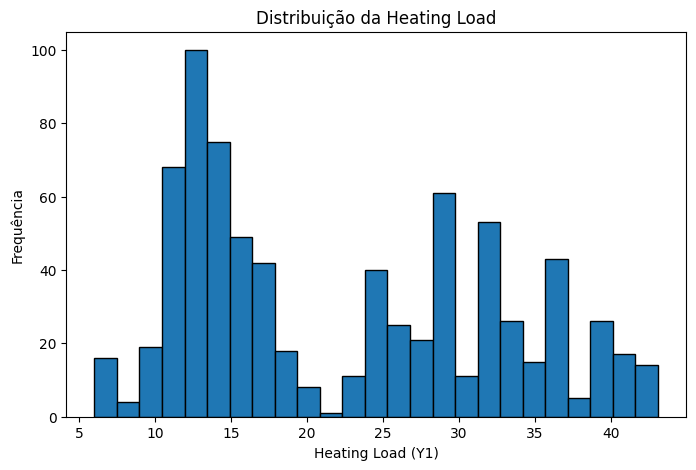

In [17]:
# Distribuição da Heating Load

plt.figure(figsize=(8, 5))

plt.hist(df["Y1"], bins=25, edgecolor="black")

plt.xlabel("Heating Load (Y1)")
plt.ylabel("Frequência")
plt.title("Distribuição da Heating Load")

plt.show()

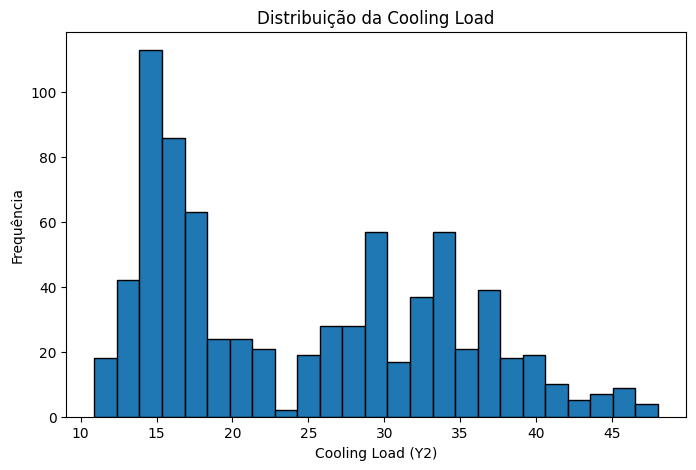

In [18]:
# Distribuição da Cooling Load

plt.figure(figsize=(8, 5))

plt.hist(df["Y2"], bins=25, edgecolor="black")

plt.xlabel("Cooling Load (Y2)")
plt.ylabel("Frequência")
plt.title("Distribuição da Cooling Load")

plt.show()

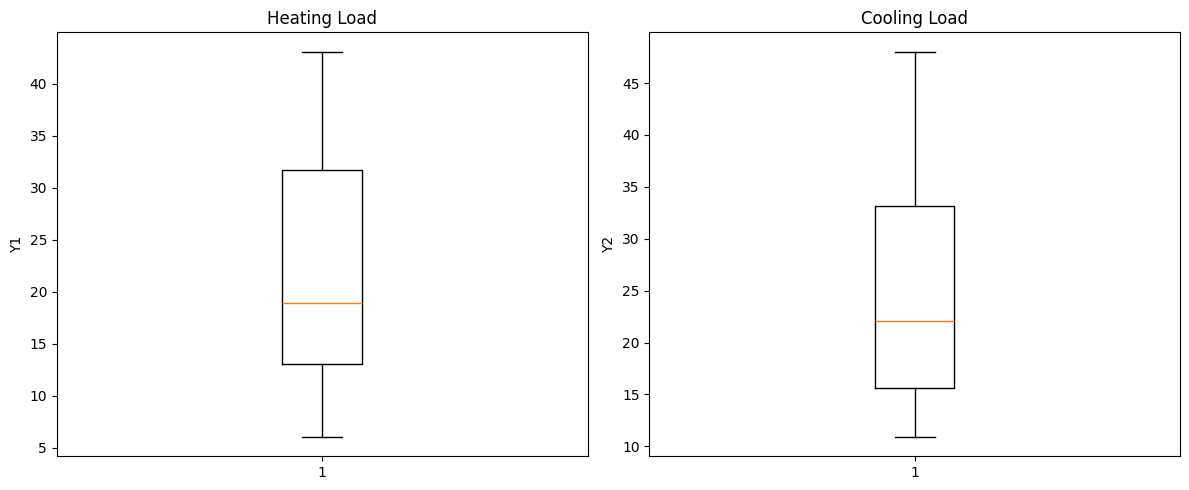

In [19]:
# Boxplots das variáveis resposta

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df["Y1"])
axes[0].set_title("Heating Load")
axes[0].set_ylabel("Y1")

axes[1].boxplot(df["Y2"])
axes[1].set_title("Cooling Load")
axes[1].set_ylabel("Y2")

plt.tight_layout()
plt.show()

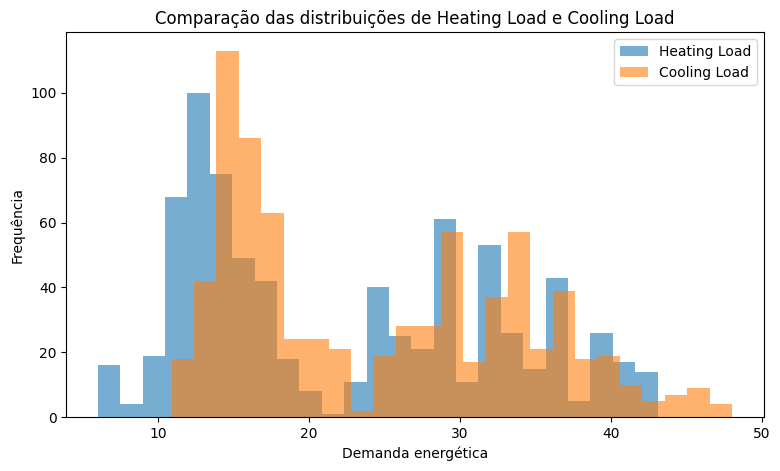

In [20]:
# Comparação das distribuições das respostas

plt.figure(figsize=(9, 5))

plt.hist(df["Y1"], bins=25, alpha=0.6, label="Heating Load")
plt.hist(df["Y2"], bins=25, alpha=0.6, label="Cooling Load")

plt.xlabel("Demanda energética")
plt.ylabel("Frequência")
plt.title("Comparação das distribuições de Heating Load e Cooling Load")
plt.legend()

plt.show()

In [21]:
# Correlação entre as variáveis resposta

response_correlation = df[["Y1", "Y2"]].corr()

display(response_correlation)

,Y1,Y2
Y1,1.000,0.976
Y2,0.976,1.000


### 2.2 Comportamento das variáveis explicativas

Nesta etapa, são investigadas a distribuição e a variabilidade das variáveis explicativas. A análise considera separadamente as variáveis quantitativas e as variáveis categóricas codificadas, respeitando a natureza de cada uma.


#### 2.2.1 Distribuição dos preditores quantitativos

As distribuições das variáveis explicativas quantitativas são examinadas por meio de histogramas, buscando identificar concentração de valores, amplitude, assimetria e possíveis características particulares de cada variável.


In [22]:
quantitative_predictors = ["X1", "X2", "X3", "X4", "X5", "X7"]

# Estatísticas descritivas das variáveis explicativas quantitativas

predictor_stats = pd.DataFrame({
    "Média": df[quantitative_predictors].mean(),
    "Mediana": df[quantitative_predictors].median(),
    "Desvio padrão": df[quantitative_predictors].std(),
    "Mínimo": df[quantitative_predictors].min(),
    "Q1": df[quantitative_predictors].quantile(0.25),
    "Q3": df[quantitative_predictors].quantile(0.75),
    "Máximo": df[quantitative_predictors].max(),
    "Assimetria": df[quantitative_predictors].skew()
})

display(predictor_stats.round(3))

,Média,Mediana,Desvio padrão,Mínimo,Q1,Q3,Máximo,Assimetria
X1,0.764,0.75,0.106,0.62,0.682,0.830,0.98,0.496
X2,671.708,673.75,88.086,514.50,606.375,741.125,808.50,-0.125
X3,318.500,318.50,43.626,245.00,294.000,343.000,416.50,0.533
X4,176.604,183.75,45.166,110.25,140.875,220.500,220.50,-0.163
X5,5.250,5.25,1.751,3.50,3.500,7.000,7.00,0.000
X7,0.234,0.25,0.133,0.00,0.100,0.400,0.40,-0.060


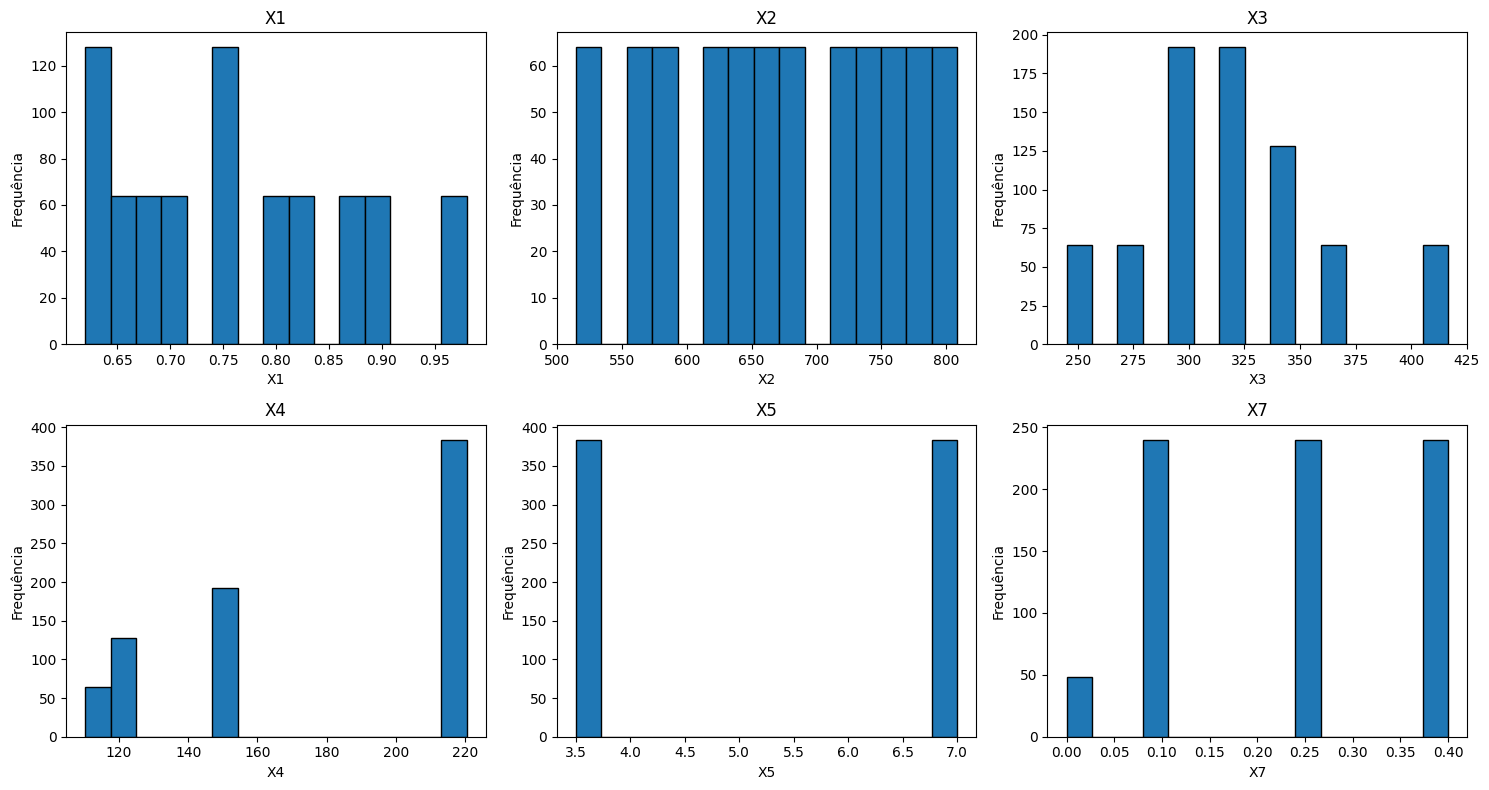

In [23]:
# Histogramas dos preditores quantitativos

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, column in zip(axes.flat, quantitative_predictors):
    ax.hist(df[column], bins=15, edgecolor="black")
    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel("Frequência")

plt.tight_layout()
plt.show()

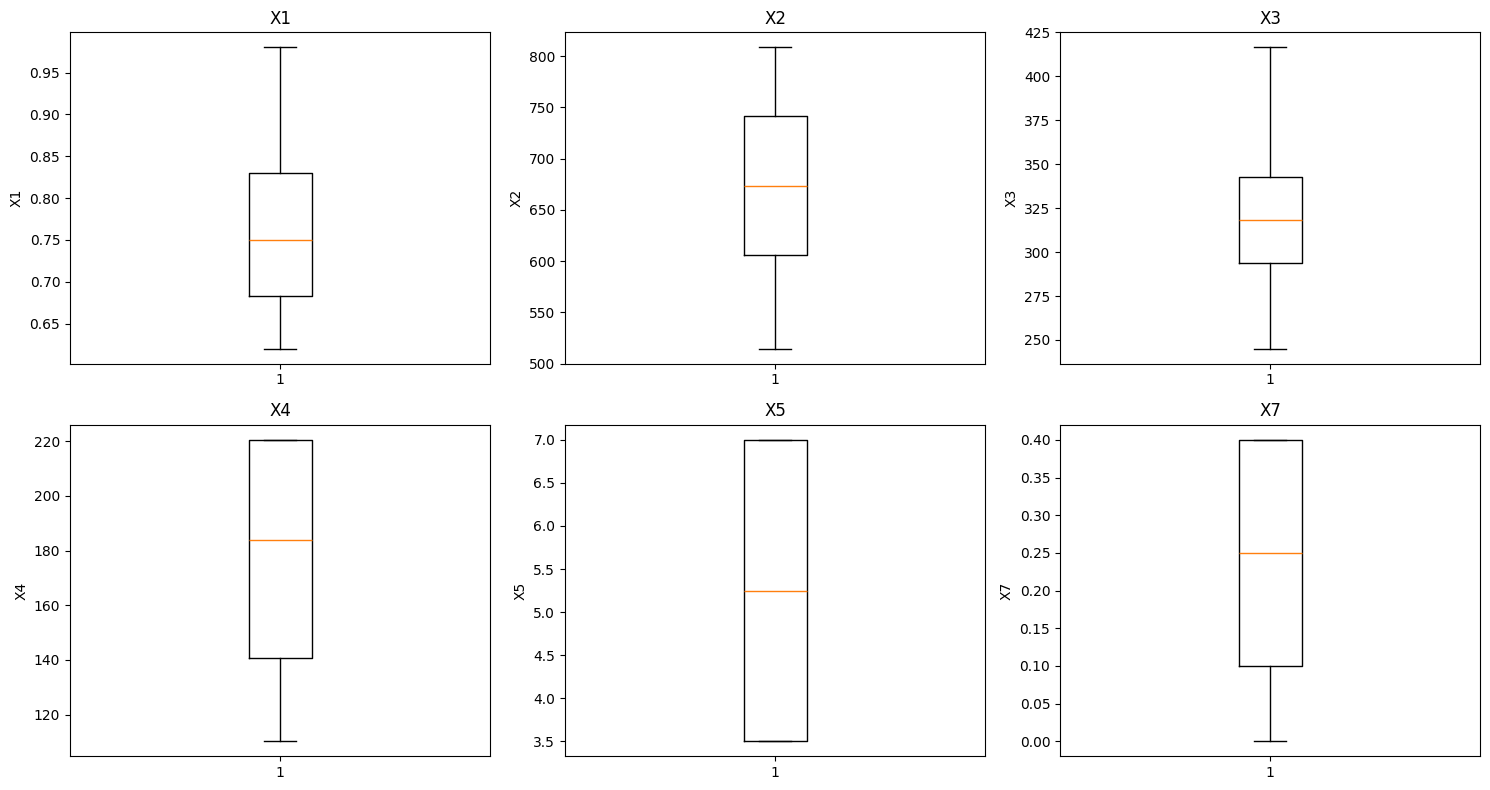

In [24]:
# Boxplots dos preditores quantitativos

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, column in zip(axes.flat, quantitative_predictors):
    ax.boxplot(df[column])
    ax.set_title(column)
    ax.set_ylabel(column)

plt.tight_layout()
plt.show()

#### 2.2.2 Variáveis categóricas

As variáveis X6 (Orientation) e X8 (Glazing Area Distribution) são analisadas por meio das frequências de seus níveis observados. Como seus valores representam categorias codificadas, não são utilizadas medidas quantitativas como média ou desvio padrão para caracterizar sua distribuição.


In [25]:
# Frequência das categorias de X6

x6_frequency = df["X6"].value_counts().sort_index()

display(x6_frequency.to_frame("Frequência"))

,Frequência
X6,
2,192
3,192
4,192
5,192


In [26]:
# Frequência das categorias de X8

x8_frequency = df["X8"].value_counts().sort_index()

display(x8_frequency.to_frame("Frequência"))

,Frequência
X8,
0,48
1,144
2,144
3,144
4,144
5,144


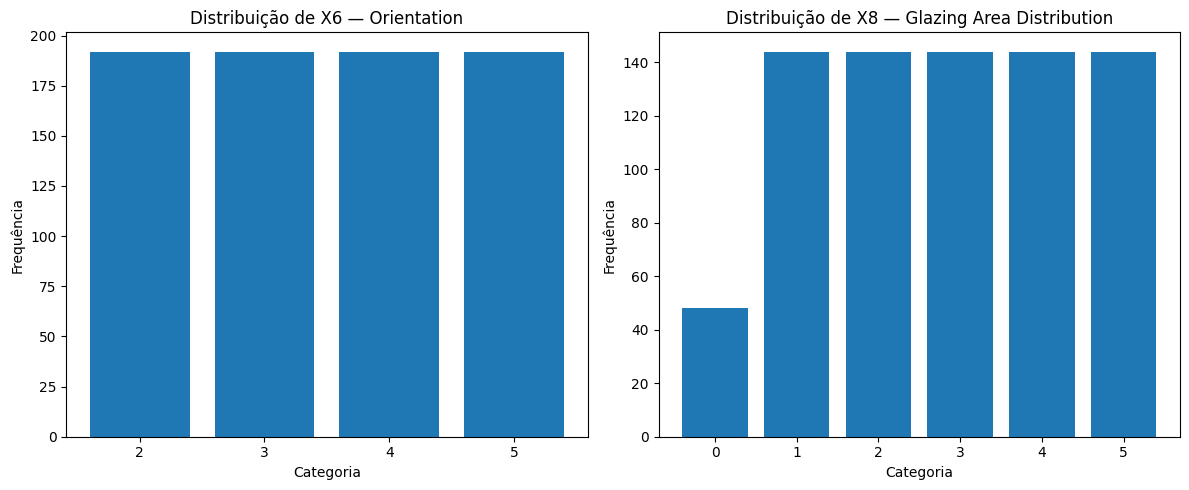

In [27]:
# Distribuição das categorias de X6 e X8

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(
    x6_frequency.index.astype(str),
    x6_frequency.values
)
axes[0].set_title("Distribuição de X6 — Orientation")
axes[0].set_xlabel("Categoria")
axes[0].set_ylabel("Frequência")

axes[1].bar(
    x8_frequency.index.astype(str),
    x8_frequency.values
)
axes[1].set_title("Distribuição de X8 — Glazing Area Distribution")
axes[1].set_xlabel("Categoria")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

In [28]:
# Valores observados nas variáveis com poucos níveis

for column in ["X5", "X7"]:
    print(f"\n{column}")
    display(
        df[column]
        .value_counts()
        .sort_index()
        .to_frame("Frequência")
    )


X5


,Frequência
X5,
3.5,384
7.0,384



X7


,Frequência
X7,
0.00,48
0.10,240
0.25,240
0.40,240


#### 2.2.3 Síntese

A análise das variáveis explicativas permite identificar diferenças de escala, dispersão e distribuição entre os preditores, além da estrutura de frequência das variáveis categóricas.

Os padrões observados nesta etapa serão considerados nas análises de associação entre os preditores e as variáveis resposta, bem como na avaliação da estrutura de dependência entre as variáveis explicativas.


### 2.3 Relações entre as variáveis explicativas

Após a análise individual dos preditores, são investigadas as relações existentes entre as variáveis explicativas. O objetivo é identificar associações relevantes entre as características dos edifícios e avaliar a estrutura de dependência entre os preditores, que será importante para a construção e interpretação dos modelos de Regressão Linear Múltipla.


In [29]:
# Matriz de correlação entre os preditores quantitativos

predictor_correlation = df[quantitative_predictors].corr()

display(predictor_correlation.round(3))

,X1,X2,X3,X4,X5,X7
X1,1.000,-0.992,-0.204,-0.869,0.828,-0.0
X2,-0.992,1.000,0.196,0.881,-0.858,0.0
X3,-0.204,0.196,1.000,-0.292,0.281,-0.0
X4,-0.869,0.881,-0.292,1.000,-0.973,-0.0
X5,0.828,-0.858,0.281,-0.973,1.000,0.0
X7,-0.000,0.000,-0.000,-0.000,0.000,1.0


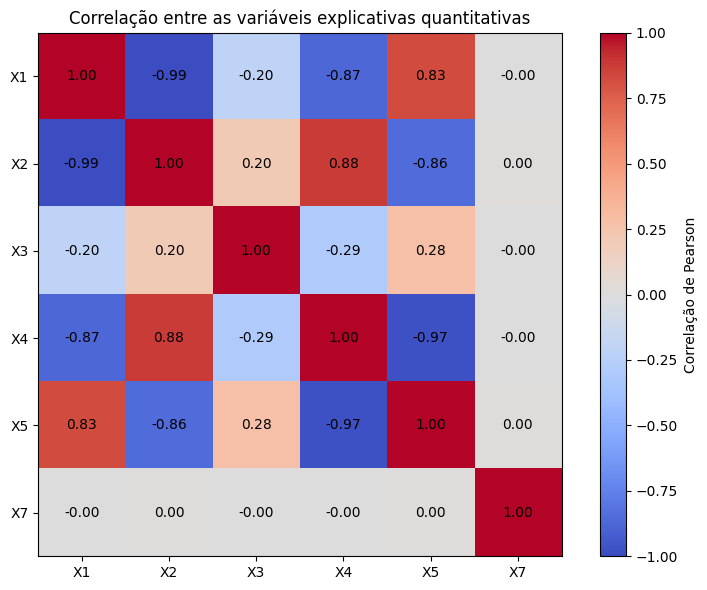

In [30]:
# Heatmap da correlação entre os preditores

plt.figure(figsize=(8, 6))

plt.imshow(
    predictor_correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlação de Pearson")

plt.xticks(
    range(len(quantitative_predictors)),
    quantitative_predictors
)

plt.yticks(
    range(len(quantitative_predictors)),
    quantitative_predictors
)

for i in range(len(predictor_correlation)):
    for j in range(len(predictor_correlation)):
        plt.text(
            j,
            i,
            f"{predictor_correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlação entre as variáveis explicativas quantitativas")
plt.tight_layout()
plt.show()

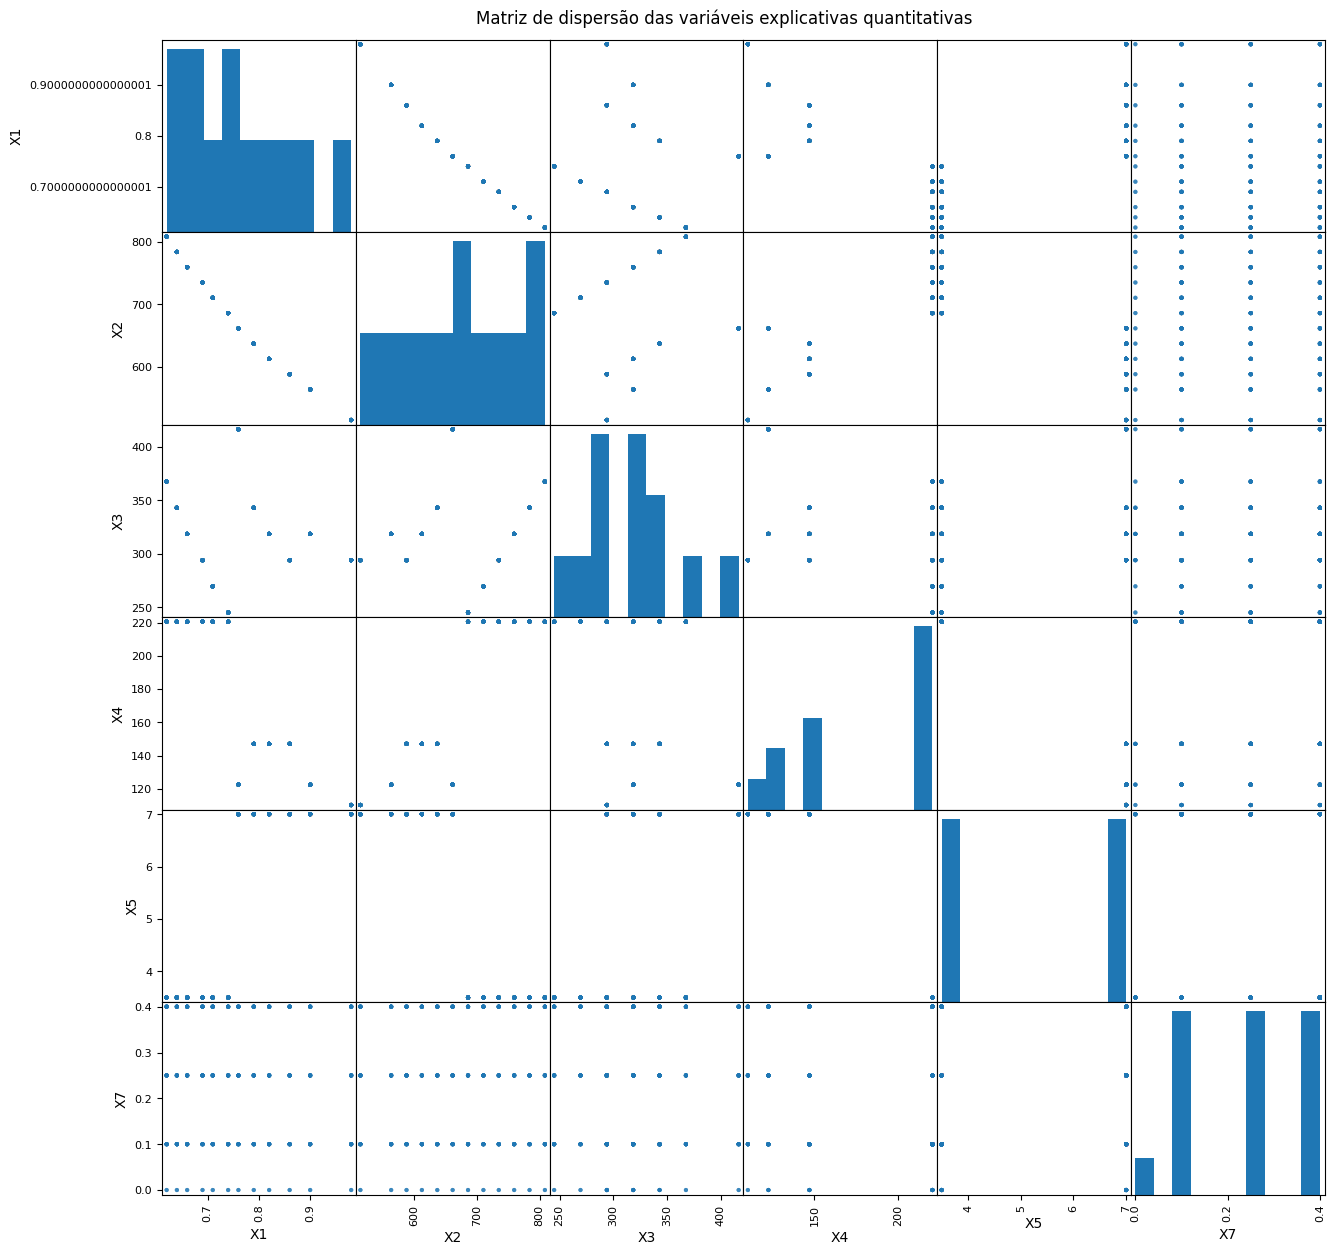

In [31]:
from pandas.plotting import scatter_matrix

# Matriz de dispersão dos preditores quantitativos

scatter_matrix(
    df[quantitative_predictors],
    figsize=(15, 15),
    diagonal="hist",
    alpha=0.4
)

plt.suptitle(
    "Matriz de dispersão das variáveis explicativas quantitativas",
    y=0.90
)

plt.show()

In [32]:
# Identificação dos pares com maior correlação absoluta

upper_triangle = predictor_correlation.where(
    np.triu(
        np.ones(predictor_correlation.shape),
        k=1
    ).astype(bool)
)

strongest_pairs = (
    upper_triangle
    .stack()
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

display(
    strongest_pairs
    .to_frame("Correlação de Pearson")
)


Correlação de Pearson
X1 X2             -9.919e-01
X4 X5             -9.725e-01
X2 X4              8.807e-01
X1 X4             -8.688e-01
X2 X5             -8.581e-01
X1 X5              8.277e-01
X3 X4             -2.923e-01
   X5              2.810e-01
X1 X3             -2.038e-01
X2 X3              1.955e-01
   X7              3.637e-15
X1 X7             -2.961e-15
X4 X7             -1.759e-15
X3 X7             -8.567e-17
X5 X7              1.489e-17

In [33]:
# Cinco pares com maior associação linear

display(
    strongest_pairs
    .head(5)
    .to_frame("Correlação de Pearson")
)

,,Correlação de Pearson
X1,X2,-0.992
X4,X5,-0.973
X2,X4,0.881
X1,X4,-0.869
X2,X5,-0.858


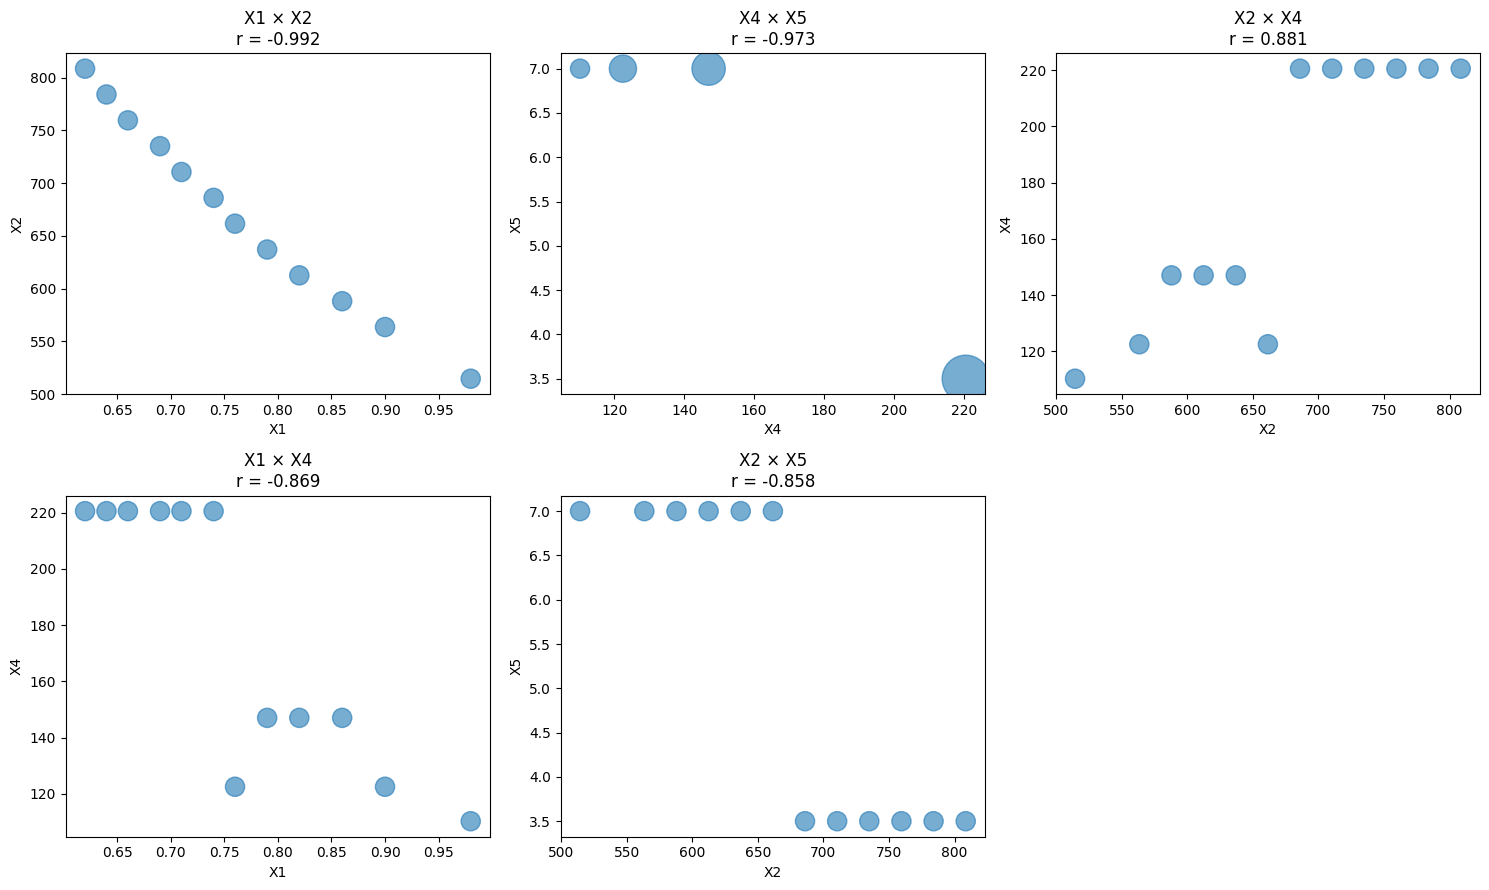

In [34]:
# Gráficos dos cinco pares mais associados
# O tamanho dos pontos representa a frequência da combinação observada

top_pairs = strongest_pairs.head(5).index

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()

for ax, (x_var, y_var) in zip(axes, top_pairs):

    pair_frequency = (
        df.groupby([x_var, y_var])
        .size()
        .reset_index(name="Frequência")
    )

    ax.scatter(
        pair_frequency[x_var],
        pair_frequency[y_var],
        s=pair_frequency["Frequência"] * 3,
        alpha=0.6
    )

    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(
        f"{x_var} × {y_var}\n"
        f"r = {predictor_correlation.loc[x_var, y_var]:.3f}"
    )

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

#### 2.3.1 Relação estrutural entre X2, X3 e X4

Além das associações identificadas pela matriz de correlação, investiga-se a existência de relações determinísticas entre as variáveis explicativas.

A análise exploratória sugere uma relação entre **Surface Area (X2)**, **Wall Area (X3)** e **Roof Area (X4)**, que será verificada diretamente nos dados.


In [35]:
# Verificação da relação X2 = X3 + 2*X4

relation_error = df["X2"] - (
    df["X3"] + 2 * df["X4"]
)

print(
    f"Maior erro absoluto: "
    f"{relation_error.abs().max():.10f}"
)

Maior erro absoluto: 0.0000000000


In [57]:
# Verificação da relação em todas as observações

relation_holds = np.allclose(
    df["X2"],
    df["X3"] + 2 * df["X4"]
)

print(
    "X2 = X3 + 2*X4 para todas as observações:",
    relation_holds
)

X2 = X3 + 2*X4 para todas as observações: True


#### 2.3.2 Interpretação das associações entre os preditores

A matriz de correlação revelou associações lineares de diferentes intensidades entre as variáveis explicativas. Destacam-se relações muito fortes, como entre **X1 e X2**, **X4 e X5** e **X2 e X4**, enquanto outras associações lineares são fracas ou praticamente inexistentes.

A análise gráfica mostrou que algumas dessas relações apresentam estruturas distintas de uma simples nuvem linear contínua, especialmente em variáveis com poucos níveis observados. Esse comportamento é compatível com a estrutura discreta de algumas características presentes no conjunto de dados.

Além das associações observadas pela correlação, foi identificada uma **relação linear determinística entre X2, X3 e X4**, dada por:

$$
X_2 = X_3 + 2X_4.
$$

A relação foi verificada para todas as observações da base. Esse resultado evidencia uma dependência estrutural entre essas variáveis geométricas, que deverá ser considerada na especificação dos modelos de Regressão Linear Múltipla.

A implicação dessa dependência para a estimação dos coeficientes será investigada com maior profundidade na etapa de modelagem.


### 2.4 Relação entre os preditores e Y1

Nesta etapa, são investigadas as relações entre as variáveis explicativas e a **Heating Load (Y1)**. Para os preditores quantitativos, são analisadas as associações lineares e monotônicas, juntamente com suas representações gráficas. Para os preditores categóricos, são comparadas as distribuições de Y1 entre seus diferentes níveis.

O objetivo é identificar quais características dos edifícios apresentam associações relevantes com a demanda de aquecimento e verificar a forma dessas relações antes da construção dos modelos de regressão.


#### 2.4.1 Variáveis quantitativas × Y1

As variáveis explicativas quantitativas são analisadas em relação à **Heating Load (Y1)** por meio de medidas de associação e representações gráficas.

São consideradas as correlações de Pearson e Spearman, além de gráficos de dispersão, buscando avaliar a direção, intensidade e forma das relações observadas.


In [36]:
# Correlações entre os preditores quantitativos e Y1

y1_correlations = pd.DataFrame({
    "Pearson": df[quantitative_predictors].corrwith(df["Y1"], method="pearson"),
    "Spearman": df[quantitative_predictors].corrwith(df["Y1"], method="spearman")
})

y1_correlations["|Pearson|"] = y1_correlations["Pearson"].abs()

display(y1_correlations.sort_values("|Pearson|", ascending=False).round(3))

,Pearson,Spearman,|Pearson|
X5,0.889,0.861,0.889
X4,-0.862,-0.804,0.862
X2,-0.658,-0.622,0.658
X1,0.622,0.622,0.622
X3,0.456,0.471,0.456
X7,0.270,0.323,0.270


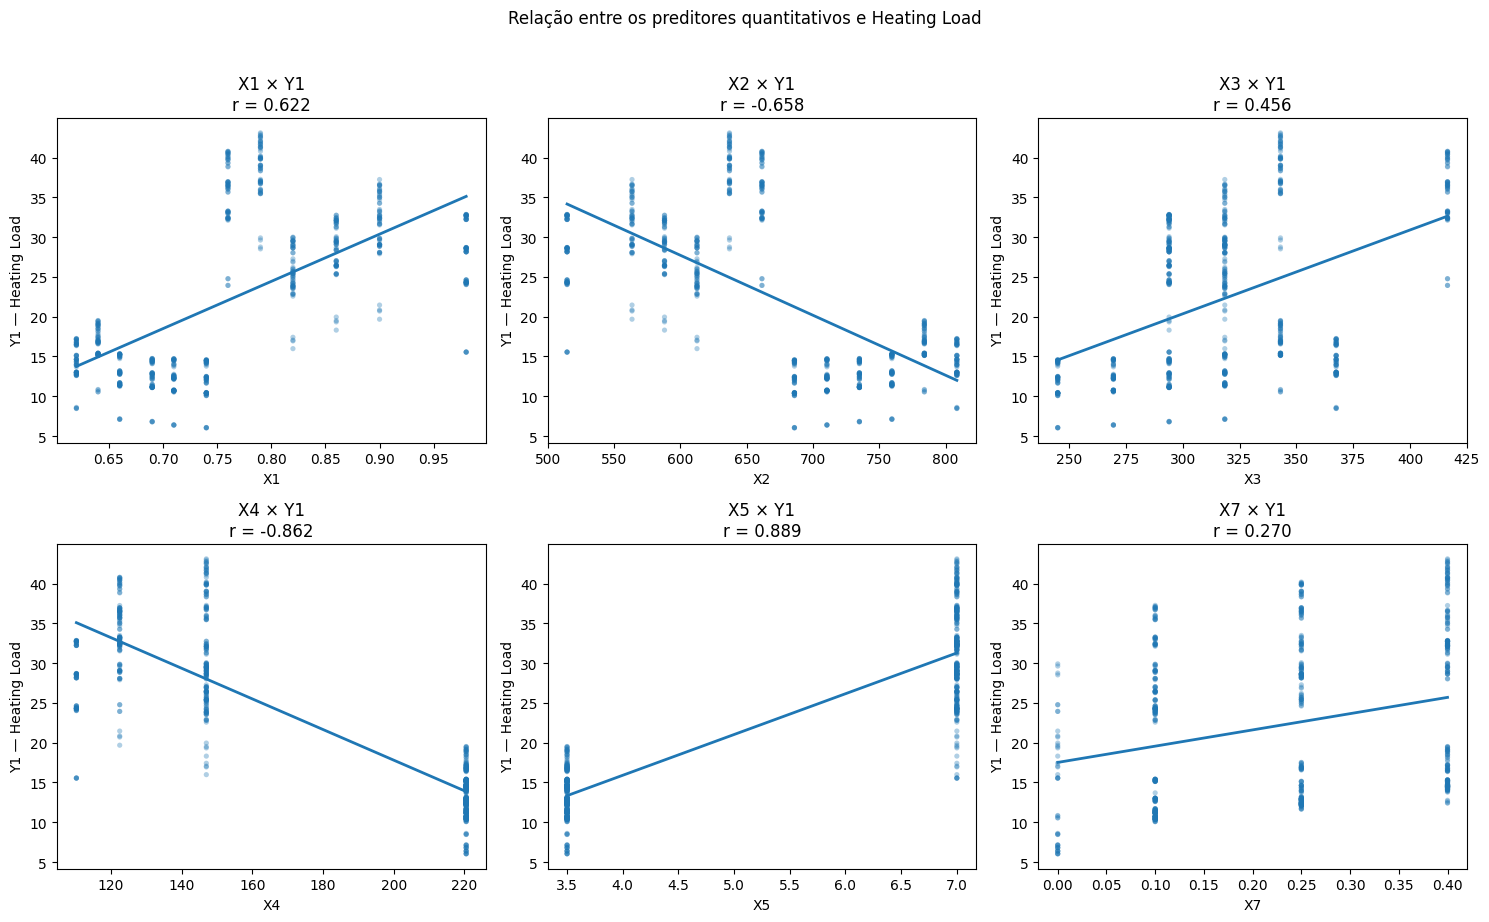

In [37]:
# Relação entre os preditores quantitativos e Y1

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, column in zip(axes.flat, quantitative_predictors):
    x = df[column]
    y = df["Y1"]

    ax.scatter(
        x,
        y,
        s=14,
        alpha=0.35,
        edgecolors="none"
    )

    # Ajuste de uma reta apenas para visualização
    coef = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = np.polyval(coef, x_line)

    ax.plot(
        x_line,
        y_line,
        linewidth=2
    )

    r = y1_correlations.loc[column, "Pearson"]

    ax.set_xlabel(column)
    ax.set_ylabel("Y1 — Heating Load")
    ax.set_title(
        f"{column} × Y1\n"
        f"r = {r:.3f}"
    )

plt.suptitle(
    "Relação entre os preditores quantitativos e Heating Load",
    y=1.02
)

plt.tight_layout()
plt.show()

In [38]:
# Preditores ordenados pela intensidade da correlação linear com Y1

y1_ranking = (
    y1_correlations["Pearson"]
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

display(
    y1_ranking
    .to_frame("Correlação de Pearson com Y1")
    .round(3)
)

,Correlação de Pearson com Y1
X5,0.889
X4,-0.862
X2,-0.658
X1,0.622
X3,0.456
X7,0.270


#### 2.4.2 Variáveis categóricas × Y1

As variáveis X6 (Orientation) e X8 (Glazing Area Distribution) são analisadas por meio da distribuição de Y1 em seus diferentes níveis.

Como seus códigos representam categorias, a comparação é realizada por meio de medidas-resumo e boxplots, em vez de correlações numéricas.


In [39]:
# Estatísticas de Y1 por categoria de X6

y1_x6_summary = (
    df.groupby("X6")["Y1"]
    .agg(
        N="count",
        Média="mean",
        Mediana="median",
        Desvio_padrão="std",
        Mínimo="min",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Máximo="max"
    )
)

display(y1_x6_summary.round(3))

,N,Média,Mediana,Desvio_padrão,Mínimo,Q1,Q3,Máximo
X6,,,,,,,,
2,192,22.313,19.130,10.109,6.07,12.958,31.695,42.77
3,192,22.381,19.005,10.140,6.05,13.000,31.720,43.10
4,192,22.260,18.950,10.119,6.01,12.912,31.660,42.74
5,192,22.275,18.650,10.071,6.04,13.020,31.645,42.96


<Figure size 800x500 with 0 Axes>

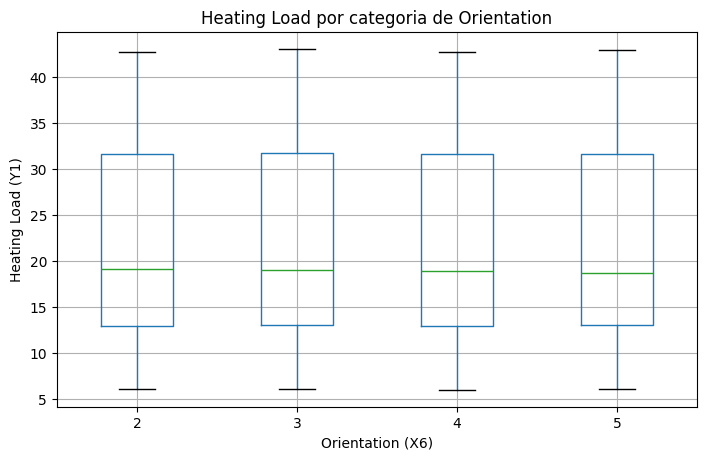

In [40]:
# Distribuição de Y1 por categoria de X6

plt.figure(figsize=(8, 5))

df.boxplot(
    column="Y1",
    by="X6"
)

plt.title("Heating Load por categoria de Orientation")
plt.suptitle("")
plt.xlabel("Orientation (X6)")
plt.ylabel("Heating Load (Y1)")

plt.show()

In [41]:
# Estatísticas de Y1 por categoria de X8

y1_x8_summary = (
    df.groupby("X8")["Y1"]
    .agg(
        N="count",
        Média="mean",
        Mediana="median",
        Desvio_padrão="std",
        Mínimo="min",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Máximo="max"
    )
)

display(y1_x8_summary.round(3))

,N,Média,Mediana,Desvio_padrão,Mínimo,Q1,Q3,Máximo
X8,,,,,,,,
0,48,14.286,13.200,7.625,6.01,7.038,19.748,29.90
1,144,23.026,21.050,10.032,10.36,14.110,32.098,42.62
2,144,22.934,20.995,10.053,10.32,13.898,32.263,43.10
3,144,22.681,20.820,9.990,10.34,13.587,32.067,42.49
4,144,22.887,20.965,10.064,10.07,14.000,32.165,42.96
5,144,22.681,20.540,10.052,10.34,12.815,32.098,42.11


<Figure size 800x500 with 0 Axes>

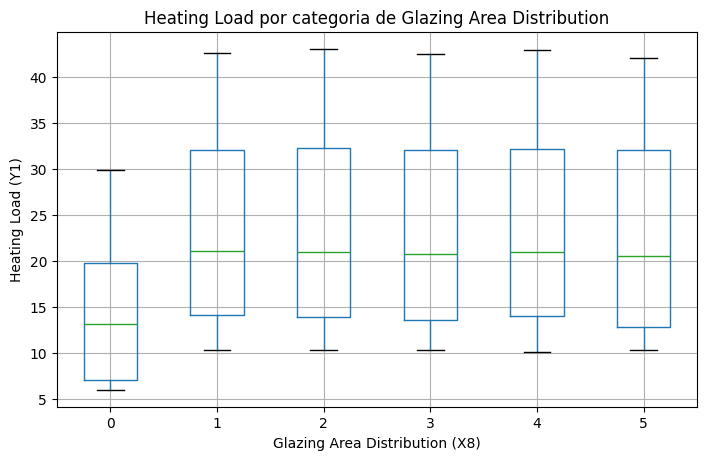

In [42]:
# Distribuição de Y1 por categoria de X8

plt.figure(figsize=(8, 5))

df.boxplot(
    column="Y1",
    by="X8"
)

plt.title("Heating Load por categoria de Glazing Area Distribution")
plt.suptitle("")
plt.xlabel("Glazing Area Distribution (X8)")
plt.ylabel("Heating Load (Y1)")

plt.show()

#### 2.4.3 Síntese das relações com Y1

A análise conjunta das correlações, dos gráficos de dispersão e das distribuições por categoria permite avaliar quais características apresentam associações mais evidentes com a Heating Load e qual é a forma dessas relações.

Os resultados serão utilizados para orientar a etapa de modelagem, especialmente na investigação da contribuição das variáveis explicativas e de possíveis relações que não sejam adequadamente representadas por uma associação linear simples.


### 2.5 Relação entre os preditores e Y2

São investigadas as relações entre as variáveis explicativas e a **Cooling Load (Y2)**, utilizando medidas de associação, gráficos de dispersão e comparações entre categorias.

Os resultados serão posteriormente comparados aos obtidos para Y1, permitindo verificar se as características dos edifícios apresentam comportamentos semelhantes ou distintos em relação às demandas de aquecimento e resfriamento.


#### 2.5.1 Variáveis quantitativas × Y2

As variáveis explicativas quantitativas são analisadas em relação à **Cooling Load (Y2)** por meio de correlações de Pearson e Spearman e de gráficos de dispersão.

A análise busca avaliar a direção, intensidade e forma das associações observadas entre cada preditor e a demanda de resfriamento.


In [43]:
# Correlações entre os preditores quantitativos e Y2

y2_correlations = pd.DataFrame({
    "Pearson": df[quantitative_predictors].corrwith(
        df["Y2"],
        method="pearson"
    ),
    "Spearman": df[quantitative_predictors].corrwith(
        df["Y2"],
        method="spearman"
    )
})

y2_correlations["|Pearson|"] = y2_correlations["Pearson"].abs()

display(
    y2_correlations
    .sort_values("|Pearson|", ascending=False)
    .round(3)
)

,Pearson,Spearman,|Pearson|
X5,0.896,0.865,0.896
X4,-0.863,-0.803,0.863
X2,-0.673,-0.651,0.673
X1,0.634,0.651,0.634
X3,0.427,0.416,0.427
X7,0.208,0.289,0.208


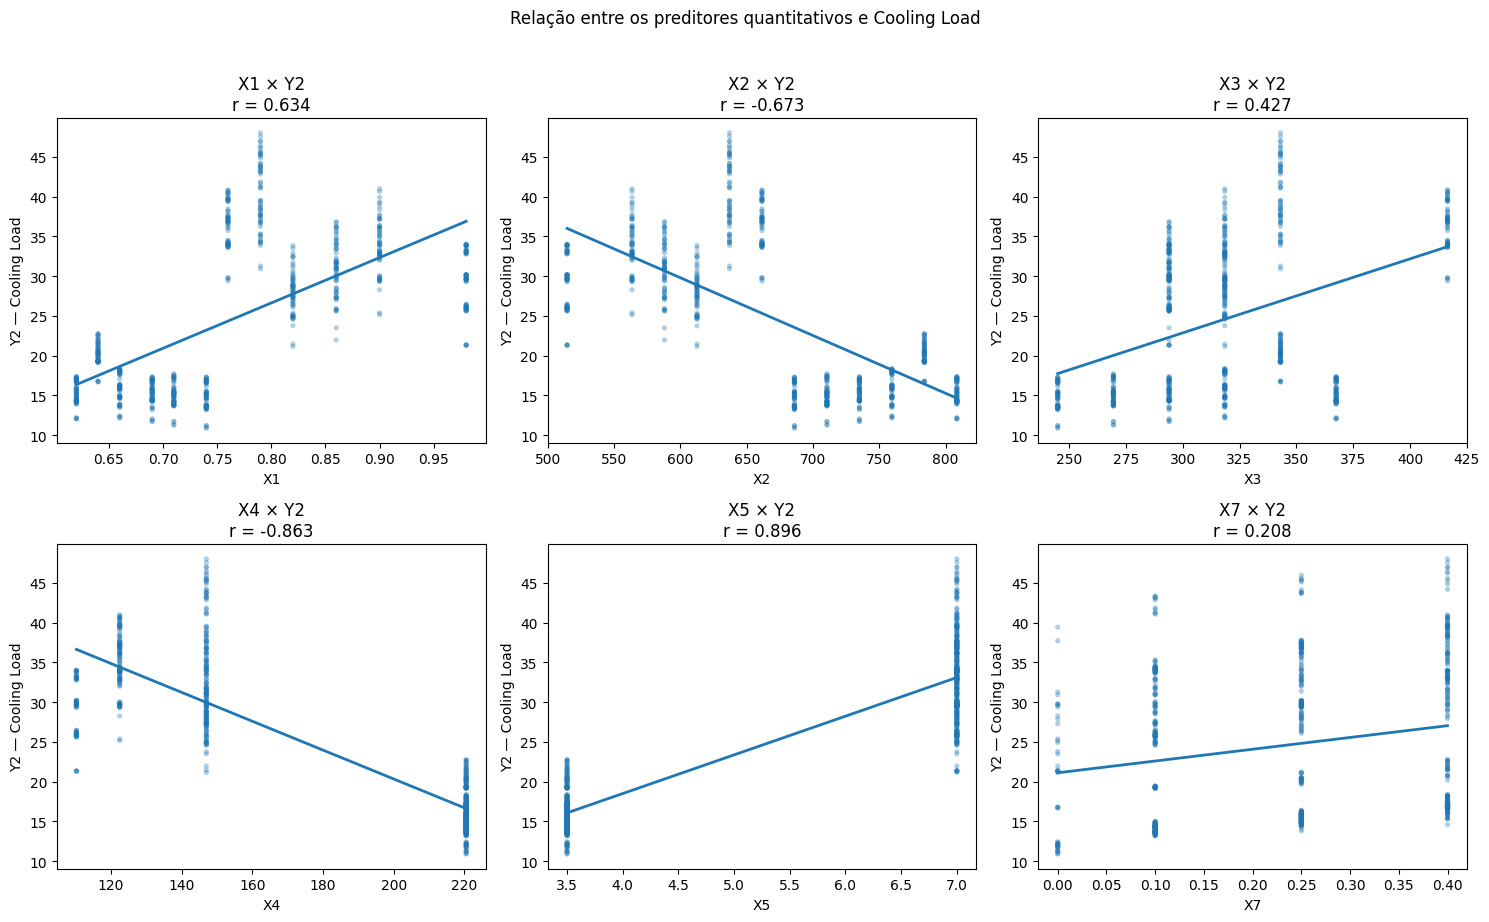

In [44]:
# Relação entre os preditores quantitativos e Y2

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, column in zip(axes.flat, quantitative_predictors):
    x = df[column]
    y = df["Y2"]

    ax.scatter(
        x,
        y,
        s=14,
        alpha=0.35,
        edgecolors="none"
    )

    # Reta de tendência apenas para visualização
    coef = np.polyfit(x, y, 1)

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = np.polyval(coef, x_line)

    ax.plot(
        x_line,
        y_line,
        linewidth=2
    )

    r = y2_correlations.loc[column, "Pearson"]

    ax.set_xlabel(column)
    ax.set_ylabel("Y2 — Cooling Load")
    ax.set_title(
        f"{column} × Y2\n"
        f"r = {r:.3f}"
    )

plt.suptitle(
    "Relação entre os preditores quantitativos e Cooling Load",
    y=1.02
)

plt.tight_layout()
plt.show()

In [45]:
# Preditores ordenados pela intensidade da correlação com Y2

y2_ranking = (
    y2_correlations["Pearson"]
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

display(
    y2_ranking
    .to_frame("Correlação de Pearson com Y2")
    .round(3)
)

,Correlação de Pearson com Y2
X5,0.896
X4,-0.863
X2,-0.673
X1,0.634
X3,0.427
X7,0.208


#### 2.5.2 Variáveis categóricas × Y2

As variáveis X6 (Orientation) e X8 (Glazing Area Distribution) são analisadas em relação à **Cooling Load (Y2)** por meio da distribuição da resposta entre seus diferentes níveis.

A comparação utiliza medidas-resumo e boxplots, permitindo verificar possíveis diferenças na demanda de resfriamento entre as categorias.


In [46]:
# Estatísticas de Y2 por categoria de X6

y2_x6_summary = (
    df.groupby("X6")["Y2"]
    .agg(
        N="count",
        Média="mean",
        Mediana="median",
        Desvio_padrão="std",
        Mínimo="min",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Máximo="max"
    )
)

display(y2_x6_summary.round(3))

,N,Média,Mediana,Desvio_padrão,Mínimo,Q1,Q3,Máximo
X6,,,,,,,,
2,192,24.605,22.220,9.609,10.90,15.495,32.952,46.44
3,192,24.313,21.755,9.310,11.19,15.620,32.870,47.59
4,192,24.480,22.170,9.375,10.94,15.638,32.830,47.01
5,192,24.954,22.510,9.813,11.17,15.802,33.698,48.03


<Figure size 800x500 with 0 Axes>

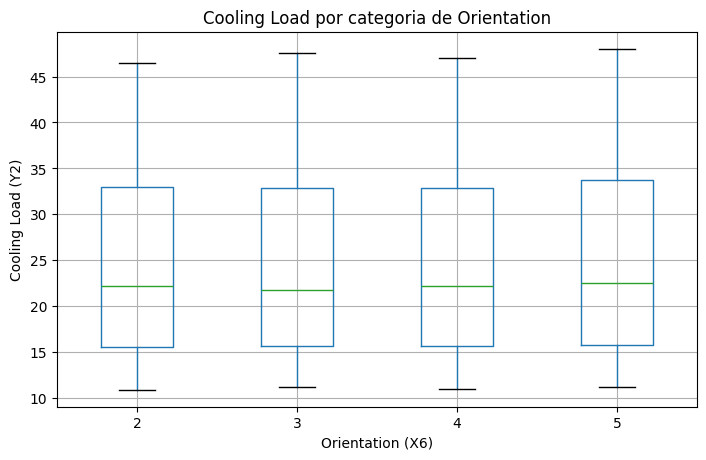

In [47]:
# Distribuição de Y2 por categoria de X6

plt.figure(figsize=(8, 5))

df.boxplot(
    column="Y2",
    by="X6"
)

plt.title("Cooling Load por categoria de Orientation")
plt.suptitle("")
plt.xlabel("Orientation (X6)")
plt.ylabel("Cooling Load (Y2)")

plt.show()

In [48]:
# Estatísticas de Y2 por categoria de X8

y2_x8_summary = (
    df.groupby("X8")["Y2"]
    .agg(
        N="count",
        Média="mean",
        Mediana="median",
        Desvio_padrão="std",
        Mínimo="min",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Máximo="max"
    )
)

display(y2_x8_summary.round(3))

,N,Média,Mediana,Desvio_padrão,Mínimo,Q1,Q3,Máximo
X8,,,,,,,,
0,48,19.706,18.980,8.134,10.90,12.048,25.860,39.44
1,144,25.180,23.670,9.554,13.43,16.130,33.412,46.94
2,144,24.997,23.445,9.559,13.20,15.865,33.472,48.03
3,144,24.659,23.235,9.489,13.36,15.462,33.258,46.44
4,144,25.015,23.550,9.562,13.20,15.920,33.685,47.59
5,144,24.715,23.085,9.530,13.44,15.260,33.512,47.01


<Figure size 800x500 with 0 Axes>

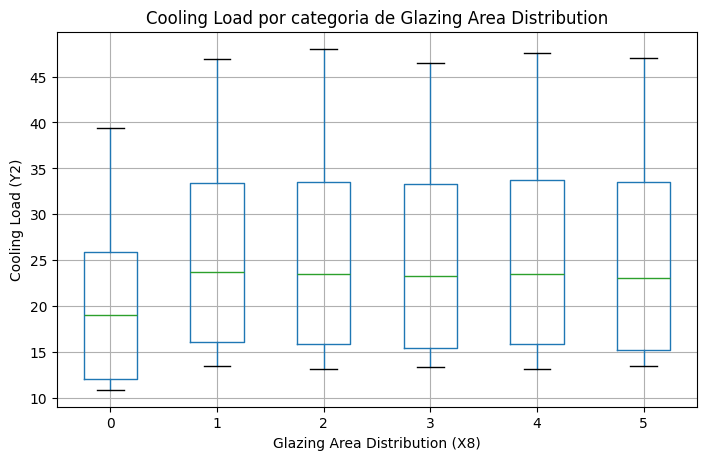

In [49]:
# Distribuição de Y2 por categoria de X8

plt.figure(figsize=(8, 5))

df.boxplot(
    column="Y2",
    by="X8"
)

plt.title("Cooling Load por categoria de Glazing Area Distribution")
plt.suptitle("")
plt.xlabel("Glazing Area Distribution (X8)")
plt.ylabel("Cooling Load (Y2)")

plt.show()

#### 2.5.3 Comparação das associações quantitativas com Y1 e Y2

As associações entre os preditores quantitativos e as duas variáveis resposta são comparadas para verificar se as características dos edifícios apresentam comportamentos semelhantes em relação à **Heating Load (Y1)** e à **Cooling Load (Y2)**.

A comparação considera os coeficientes de correlação de Pearson e Spearman, permitindo avaliar tanto as associações lineares quanto as relações monotônicas observadas.


In [50]:
# Comparação das correlações dos preditores com Y1 e Y2

correlation_comparison = pd.DataFrame({
    "Pearson — Y1": y1_correlations["Pearson"],
    "Pearson — Y2": y2_correlations["Pearson"],
    "Spearman — Y1": y1_correlations["Spearman"],
    "Spearman — Y2": y2_correlations["Spearman"]
})

display(correlation_comparison.round(3))

,Pearson — Y1,Pearson — Y2,Spearman — Y1,Spearman — Y2
X1,0.622,0.634,0.622,0.651
X2,-0.658,-0.673,-0.622,-0.651
X3,0.456,0.427,0.471,0.416
X4,-0.862,-0.863,-0.804,-0.803
X5,0.889,0.896,0.861,0.865
X7,0.270,0.208,0.323,0.289


In [51]:
# Diferença entre as correlações de Pearson

correlation_comparison["Diferença Pearson"] = (
    correlation_comparison["Pearson — Y2"]
    - correlation_comparison["Pearson — Y1"]
)

display(
    correlation_comparison[
        ["Pearson — Y1", "Pearson — Y2", "Diferença Pearson"]
    ].round(3)
)

,Pearson — Y1,Pearson — Y2,Diferença Pearson
X1,0.622,0.634,0.012
X2,-0.658,-0.673,-0.015
X3,0.456,0.427,-0.029
X4,-0.862,-0.863,-0.001
X5,0.889,0.896,0.006
X7,0.270,0.208,-0.062


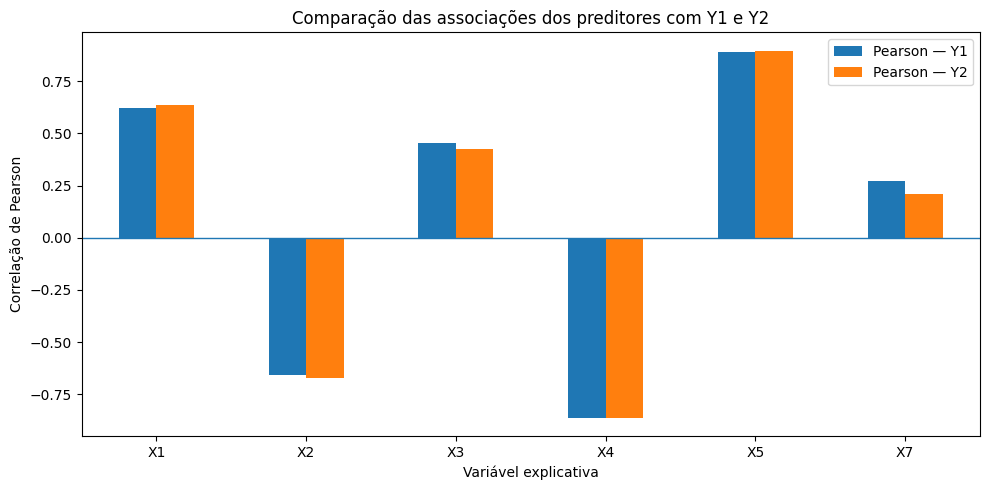

In [52]:
# Comparação das correlações de Pearson com Y1 e Y2

correlation_comparison[
    ["Pearson — Y1", "Pearson — Y2"]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.axhline(0, linewidth=1)

plt.xlabel("Variável explicativa")
plt.ylabel("Correlação de Pearson")
plt.title(
    "Comparação das associações dos preditores com Y1 e Y2"
)

plt.xticks(rotation=0)
plt.legend()

plt.tight_layout()
plt.show()

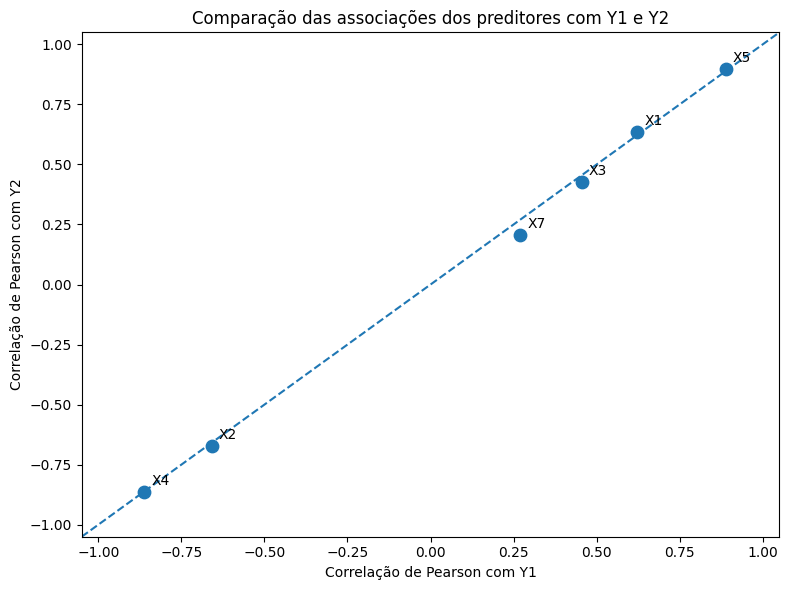

In [53]:
# Associação dos preditores com Y1 versus Y2

plt.figure(figsize=(8, 6))

plt.scatter(
    correlation_comparison["Pearson — Y1"],
    correlation_comparison["Pearson — Y2"],
    s=80
)

for variable in correlation_comparison.index:
    x = correlation_comparison.loc[variable, "Pearson — Y1"]
    y = correlation_comparison.loc[variable, "Pearson — Y2"]

    plt.annotate(
        variable,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )

# Linha y = x para referência
lim = 1.05

plt.plot(
    [-lim, lim],
    [-lim, lim],
    linestyle="--"
)

plt.xlim(-lim, lim)
plt.ylim(-lim, lim)

plt.xlabel("Correlação de Pearson com Y1")
plt.ylabel("Correlação de Pearson com Y2")
plt.title("Comparação das associações dos preditores com Y1 e Y2")

plt.tight_layout()
plt.show()

A comparação entre as correlações permite verificar a semelhança ou diferença das associações dos preditores com as duas respostas. Padrões próximos entre Y1 e Y2 indicam comportamentos semelhantes das características analisadas em relação às demandas de aquecimento e resfriamento, enquanto diferenças relevantes podem indicar que determinados preditores estão associados de maneira distinta às duas respostas.

A interpretação desses resultados será realizada conjuntamente com os gráficos de dispersão e demais análises exploratórias.


### 2.6 Investigação de valores extremos e observações atípicas

A presença de valores extremos é investigada nas variáveis quantitativas por meio do critério baseado no intervalo interquartil (IQR). O objetivo é identificar observações potencialmente atípicas para posterior investigação, sem classificá-las automaticamente como erros ou removê-las da base.

A análise exploratória é utilizada apenas para sinalizar observações que merecem atenção. A influência efetiva dessas observações sobre os modelos será investigada posteriormente na etapa de diagnóstico da regressão.


In [54]:
# Variáveis quantitativas

quantitative_vars = [
    "X1", "X2", "X3", "X4", "X5", "X7", "Y1", "Y2"
]

In [55]:
# Limites para identificação de valores potencialmente atípicos

outlier_limits = pd.DataFrame({
    "Q1": df[quantitative_vars].quantile(0.25),
    "Q3": df[quantitative_vars].quantile(0.75)
})

outlier_limits["IQR"] = (
    outlier_limits["Q3"] - outlier_limits["Q1"]
)

outlier_limits["Limite inferior"] = (
    outlier_limits["Q1"] - 1.5 * outlier_limits["IQR"]
)

outlier_limits["Limite superior"] = (
    outlier_limits["Q3"] + 1.5 * outlier_limits["IQR"]
)

display(outlier_limits.round(3))

,Q1,Q3,IQR,Limite inferior,Limite superior
X1,0.682,0.830,0.147,0.461,1.051
X2,606.375,741.125,134.750,404.250,943.250
X3,294.000,343.000,49.000,220.500,416.500
X4,140.875,220.500,79.625,21.438,339.938
X5,3.500,7.000,3.500,-1.750,12.250
X7,0.100,0.400,0.300,-0.350,0.850
Y1,12.992,31.668,18.675,-15.020,59.680
Y2,15.620,33.132,17.512,-10.649,59.401


In [56]:
# Quantidade de valores potencialmente atípicos por variável

outlier_counts = {}

for column in quantitative_vars:
    lower = outlier_limits.loc[column, "Limite inferior"]
    upper = outlier_limits.loc[column, "Limite superior"]

    mask = (df[column] < lower) | (df[column] > upper)

    outlier_counts[column] = mask.sum()

outlier_counts = (
    pd.Series(outlier_counts, name="Valores potencialmente atípicos")
)

display(outlier_counts.to_frame())

,Valores potencialmente atípicos
X1,0
X2,0
X3,0
X4,0
X5,0
X7,0
Y1,0
Y2,0


### 2.7 Síntese da análise exploratória

A análise exploratória permitiu identificar características relevantes para a etapa de modelagem. As variáveis resposta apresentaram comportamento semelhante, com a **Cooling Load (Y2)** apresentando valores, em geral, superiores à **Heating Load (Y1)**, além de uma associação linear muito forte entre ambas.

Entre as variáveis explicativas, foram observadas associações de diferentes intensidades, com destaque para relações muito fortes entre **X1 e X2**, **X4 e X5** e **X2 e X4**. Esses resultados indicam uma forte dependência entre algumas das características geométricas dos edifícios.

Além das associações observadas pela correlação, foi identificada e confirmada uma **relação linear determinística entre X2, X3 e X4**, dada por:

$$
X_2 = X_3 + 2X_4.
$$

A relação é válida para todas as observações da base, evidenciando uma dependência estrutural exata entre essas variáveis.

As análises das relações entre os preditores e as variáveis resposta também permitiram identificar características associadas às demandas de aquecimento e resfriamento, além de diferenças observadas entre os níveis das variáveis categóricas.

Na investigação de valores extremos pelo critério do intervalo interquartil, não foram identificadas observações potencialmente atípicas.

De maneira geral, a principal questão identificada para a etapa de modelagem é a **dependência entre algumas variáveis explicativas**, especialmente a relação linear determinística entre X2, X3 e X4. Essa estrutura deverá ser considerada na especificação dos modelos de Regressão Linear Múltipla e será investigada com maior profundidade na etapa de modelagem, incluindo suas consequências para a estimação e interpretação dos coeficientes.
